In [30]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250922-clSigma-param-scan',
    []
)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)
round_metrics_df['dms_shortname'] = round_metrics_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading results for DMSs: {'SHOC2_HUMAN_Kwon_2022', 'HXK4_HUMAN_Gersing_2022_activity', 'ANCSZ_Hobbs_2022', 'PPM1D_HUMAN_Miller_2022', 'HSP82_YEAST_Flynn_2019', 'BLAT_ECOLX_Firnberg_2014', 'OXDA_RHOTO_Vanella_2023_activity', 'CBS_HUMAN_Sun_2020', 'HEM3_HUMAN_Loggerenberg_2023'}


In [31]:
round_metrics_df.config_name.unique()

array(['FolDE-clS3', 'FolDE-clS10', 'FolDE-clS2', 'FolDE-clS4',
       'FolDE-clS3-schedule', 'FolDE-clS100', 'FolDE-clS6-schedule',
       'FolDE-clS1-schedule', 'FolDE-clS025', 'FolDE-clS6', 'FolDE-clS1'],
      dtype=object)

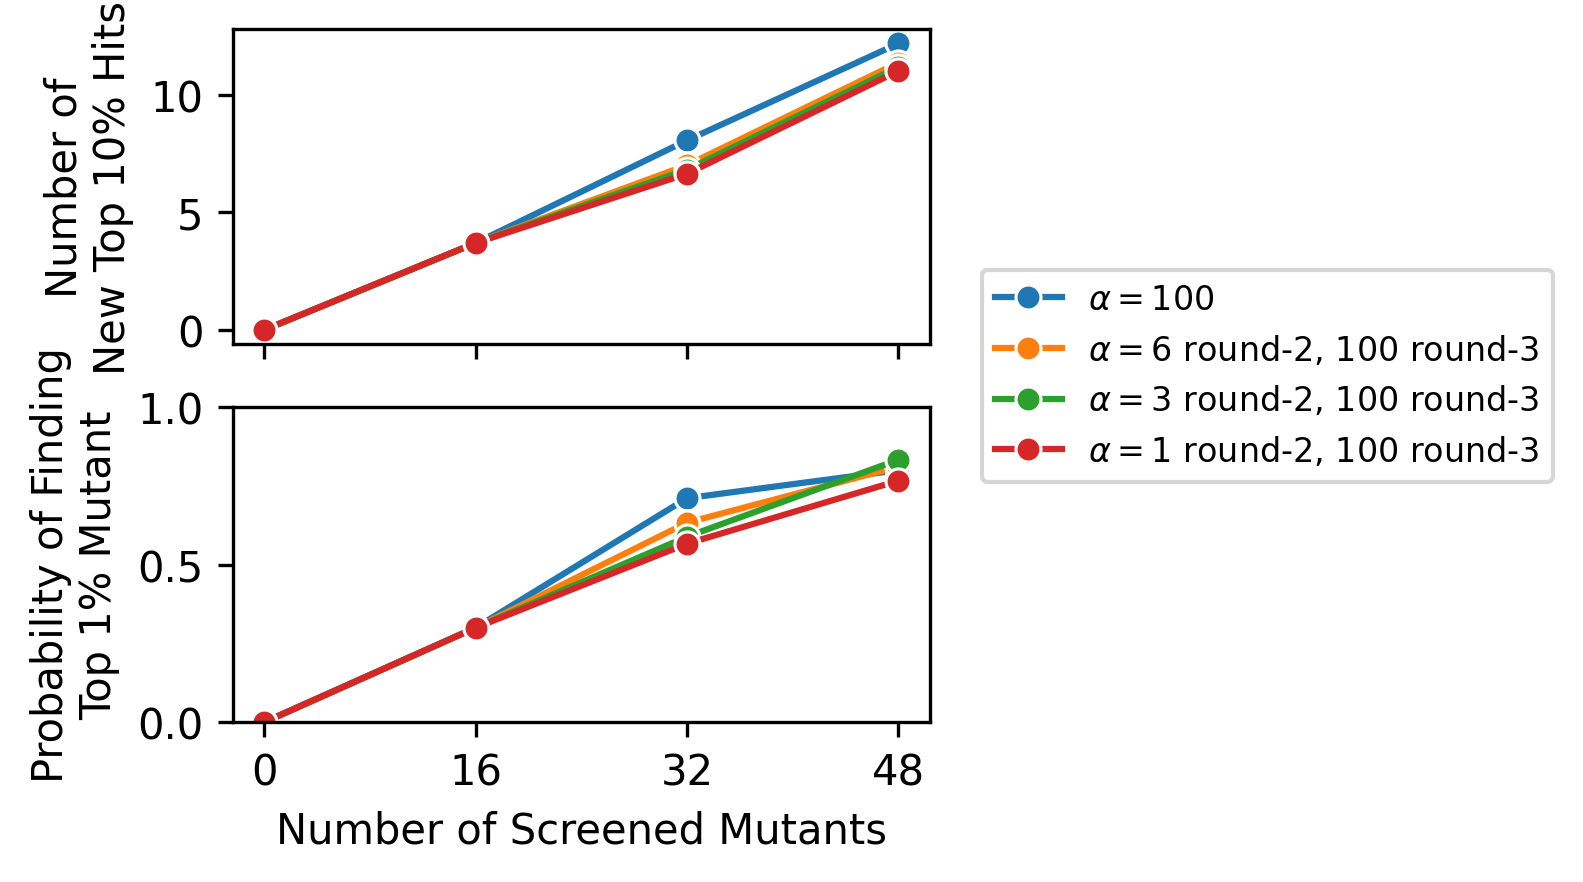

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import re
import pandas as pd

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3, 3), sharex=True, dpi=300)

CONFIGS = [c for c in round_metrics_df.config_name.unique()]# if ('base' in c or '-sp-' in c)]# or 'no-naturalnessTraining' in c)]
plot_df = round_metrics_df[round_metrics_df.config_name.isin(CONFIGS)].copy()
def get_cl_params(config_name):
    m = re.match(r'FolDE-clS(0?)(\d+)', config_name)
    schedule_m = re.match(r'FolDE-clS(0?)(\d+)-schedule', config_name)
    assert m or schedule_m

    is_schedule = schedule_m is not None

    matching_m = m if m else schedule_m
    is_decimal = matching_m.groups()[0] == '0'
    if is_decimal:
        sigma_str = f'0.{matching_m.groups()[1]}'
    else:
        sigma_str = matching_m.groups()[1]
    sigma = float(sigma_str)
    sigma_str = '$\\alpha=$' + sigma_str + (' round-2, 100 round-3' if is_schedule else '')
    return sigma_str, sigma, is_schedule

plot_df['Screened mutants'] = plot_df.round_num * 16
plot_df = pd.concat([plot_df, pd.DataFrame([{
    'config_name': config_name,
    'Screened mutants': 0,
    'round_num': 0,
    'cumulative_10pct_hits': 0,
    'has_found_top_1pct': 0,
} for config_name in CONFIGS])]).reset_index()

plot_df['sigma_str'] = plot_df.config_name.apply(lambda x: get_cl_params(x)[0])
plot_df['sigma'] = plot_df.config_name.apply(lambda x: get_cl_params(x)[1])
plot_df['is_schedule'] = plot_df.config_name.apply(lambda x: get_cl_params(x)[2])
plot_df = plot_df.sort_values('sigma', ascending=False)
plot_df = plot_df[plot_df.round_num <= 3]
plot_df = plot_df[plot_df.sigma.isin([1, 3, 6, 100])]
plot_df = plot_df[(plot_df.sigma == 100) | (plot_df.is_schedule == True)]
sigma_order = plot_df[~plot_df.sigma_str.duplicated()].sigma_str.tolist()

for ax, metric in zip(
    [
        ax1,
        ax2
    ], [
        'cumulative_10pct_hits',
        # 'new_10pct_hits',
        'has_found_top_1pct'
    ]):
    sns.lineplot(
        ax=ax,
        data=plot_df,
        # y='held_out_activity_spearman',
        y=metric,
        # y='held_out_1pct_auc',
        # y='held_out_activity_spearman',
        x='Screened mutants',
        hue='sigma_str',
        errorbar=None,
        marker='o',
        hue_order=sigma_order,
        # style='noise'
        # style='config_name',
        # errorbar=None
    )

# Disable ax1 legend
ax1.get_legend().remove()
ax2.legend(
    # title='Workflow',
    loc='center left',
    bbox_to_anchor=(1.05, 1.1),
    fontsize=8
)
ax2.set_xlabel('Number of Screened Mutants')

ax1.set_ylabel('Number of\nNew Top 10% Hits')
ax2.set_ylabel('Probability of Finding\nTop 1% Mutant')
ax2.set_xticks([0, 16, 32, 48])
ax2.set_ylim(0, 1)

plt.savefig('notebooks/jacob/paperplots/sup_cl_tuning.png', dpi=300, bbox_inches='tight')


In [13]:
three_round_avg = round_metrics_df[round_metrics_df.round_num <= 3].groupby(['dms_id', 'config_name']).agg({'held_out_1pct_recall': 'mean', 'held_out_10pct_recall': 'mean'})
enrichments = (three_round_avg.held_out_1pct_recall / 0.01 + three_round_avg.held_out_10pct_recall / 0.1).rename('enrichments')
enrichments = enrichments.reset_index()
enrichments.groupby('config_name').agg({'enrichments': 'mean'}).sort_values('enrichments', ascending=False)

,enrichments
config_name,
FolDE-clS025,6.419511
FolDE-clS100,6.371516
FolDE-clS1000,6.348093
FolDE-clS01,6.285376
FolDE-clS05,6.282810
FolDE-clS4,6.275855
FolDE-clS1,6.264905
FolDE-clS2,6.190475
